In [74]:
# Cell 1: Import necessary libraries
import numpy as np
import random
import matplotlib.pyplot as plt
from collections import deque
import sys

# Configure plot style (optional)
plt.style.use('seaborn-v0_8-whitegrid')
#%matplotlib inline # Uncomment if plots aren't showing inline

In [112]:
# Cell 2: Define the Meta-Heuristic Hybrid Optimizer (Constraints & Deviation Prioritized)
class HybridPowerFlowOptimizer:
    # Added load_shed_costs
    def __init__(self, A_matrix, line_limits, gen_costs, gen_limits_min, gen_limits_max, load_shed_costs, initial_B, memory_size=100):
        self.A = A_matrix
        self.line_limits = np.array(line_limits, dtype=np.float64)
        self.num_buses = A_matrix.shape[1]
        self.tolerance = 1e-6

        self.initial_B = initial_B.copy().flatten()

        self.gen_indices = np.where(self.initial_B > self.tolerance)[0]
        self.load_indices = np.where(self.initial_B <= self.tolerance)[0]

        if len(self.gen_indices) == 0: raise ValueError("No generator buses identified.")

        print(f"Identified {len(self.gen_indices)} generator buses (indices: {self.gen_indices})")
        print(f"Identified {len(self.load_indices)} load buses (indices: {self.load_indices}) - Load shedding enabled.")

        # Store costs and limits ONLY for generators
        flat_gen_costs=np.array(gen_costs, dtype=np.float64).flatten(); flat_gen_limits_min=np.array(gen_limits_min, dtype=np.float64).flatten(); flat_gen_limits_max=np.array(gen_limits_max, dtype=np.float64).flatten()
        if len(flat_gen_costs)!=self.num_buses or len(flat_gen_limits_min)!=self.num_buses or len(flat_gen_limits_max)!=self.num_buses: raise ValueError(f"Gen cost/limit arrays must have length {self.num_buses}")
        self.gen_costs_only=flat_gen_costs[self.gen_indices]; self.gen_limits_min_only=flat_gen_limits_min[self.gen_indices]; self.gen_limits_max_only=flat_gen_limits_max[self.gen_indices]

        # Store costs and limits for LOADS
        flat_load_shed_costs=np.array(load_shed_costs, dtype=np.float64).flatten()
        if len(flat_load_shed_costs)!=self.num_buses: raise ValueError(f"Load shed cost array must have length {self.num_buses}")
        self.load_shed_costs_only=flat_load_shed_costs[self.load_indices]
        self.initial_B_load_fixed=self.initial_B[self.load_indices]; self.load_limits_min_only=self.initial_B_load_fixed; self.load_limits_max_only=np.zeros_like(self.load_limits_min_only)

        # Check and adjust initial B for generators
        initial_gen_values=self.initial_B[self.gen_indices]; needs_adjust=False
        if np.any(initial_gen_values < self.gen_limits_min_only - self.tolerance) or np.any(initial_gen_values > self.gen_limits_max_only + self.tolerance):
            print("Warning: Initial B outside gen limits. Clamping..."); clamped_gen_values=np.clip(initial_gen_values, self.gen_limits_min_only, self.gen_limits_max_only); self.initial_B[self.gen_indices]=clamped_gen_values; needs_adjust=True
        req_gen_init=-np.sum(self.initial_B_load_fixed); cur_gen_init=np.sum(self.initial_B[self.gen_indices]); diff_init=req_gen_init-cur_gen_init; num_gens=len(self.gen_indices)
        if abs(diff_init) > self.tolerance * max(1, num_gens):
             print(f"Warning: Initial B sum diff {diff_init:.4f}. Adjusting gens..."); needs_adjust=True
             if num_gens > 0:
                  self.initial_B[self.gen_indices] += diff_init / num_gens; self.initial_B[self.gen_indices]=np.clip(self.initial_B[self.gen_indices], self.gen_limits_min_only, self.gen_limits_max_only)
                  final_adj_sum=np.sum(self.initial_B);
                  if abs(final_adj_sum) > self.tolerance * self.num_buses * 10: # Check sum after adjustment
                      print(f"ERROR: Could not balance initial state. Sum: {final_adj_sum:.6f}")
             else: print("ERROR: Cannot balance - no generators.")
        if needs_adjust: print("-> Adjusted initial B state used for optimization:", self.initial_B)

        self.memory=deque(maxlen=memory_size)

    # _apply_constraints remains the same
    def _apply_constraints(self, solution_vector):
        sol=solution_vector.copy().flatten(); sol[self.load_indices]=self.initial_B_load_fixed
        try: sol[self.load_indices]=np.clip(sol[self.load_indices], self.load_limits_min_only, self.load_limits_max_only)
        except IndexError: print("Warn: Load clamp idx")
        try: sol[self.gen_indices]=np.clip(sol[self.gen_indices], self.gen_limits_min_only, self.gen_limits_max_only)
        except IndexError: print("Warn: Gen clamp idx")
        gen_values=sol[self.gen_indices]; load_values=sol[self.load_indices]; num_gens=len(gen_values)
        if num_gens > 0:
            req_gen=-np.sum(load_values); cur_gen=np.sum(gen_values); diff=req_gen-cur_gen
            if abs(diff) > self.tolerance * num_gens: gen_values += diff / num_gens; sol[self.gen_indices]=np.clip(gen_values, self.gen_limits_min_only, self.gen_limits_max_only)
            final_gen_sum=np.sum(sol[self.gen_indices]); final_diff=req_gen-final_gen_sum
            if abs(final_diff) > self.tolerance * num_gens: gen_values_final=sol[self.gen_indices]; gen_values_final += final_diff / num_gens; sol[self.gen_indices]=np.clip(gen_values_final, self.gen_limits_min_only, self.gen_limits_max_only)
        return sol.reshape(-1, 1)

    # optimize remains the same
    def optimize(self, B_unused, iterations=200, population_size=30, alpha=0.7):
        initial_state_constrained = self._apply_constraints(self.initial_B)
        initial_population = [self._generate_random_solution() for _ in range(population_size)]
        initial_population[0] = initial_state_constrained
        best_solution = initial_state_constrained.copy(); best_fitness = self._calculate_fitness(best_solution)
        fitness_history = [best_fitness] if np.isfinite(best_fitness) else []
        algorithm_contributions = {'OOA': 0, 'KHA': 0, 'SHO': 0}
        for iteration in range(iterations):
            if iteration < iterations*0.3: weights=[0.2,0.6,0.2]
            elif iteration < iterations*0.7: weights=[0.3,0.3,0.4]
            else: weights=[0.6,0.2,0.2]
            new_population = []
            for i in range(population_size):
                algorithm = random.choices(['OOA', 'KHA', 'SHO'], weights=weights, k=1)[0]; current_solution = initial_population[i]
                if algorithm=='OOA': candidate_solution=self._apply_orcas_optimization(initial_population,i,best_solution,iteration,iterations)
                elif algorithm=='KHA': candidate_solution=self._apply_krill_herd(initial_population,i,best_solution,iteration,iterations)
                else: candidate_solution=self._apply_spotted_hyena(initial_population,i,best_solution,iteration,iterations)
                algorithm_contributions[algorithm]+=1
                new_solution=self._apply_constraints(candidate_solution); new_population.append(new_solution)
                fitness=self._calculate_fitness(new_solution)
                if np.isfinite(fitness) and fitness < best_fitness:
                    best_fitness=fitness; best_solution=new_solution.copy()
                    if iteration % 100 == 0 and i == 0: deviation=self._get_generator_deviation(best_solution); cost=self._get_rescheduling_cost(best_solution); load_shed_cost=self._get_load_shed_cost(best_solution); print(f"Iter {iteration}: Fit={best_fitness:.2f}, Dev={deviation:.2f}, GenCost={cost:.2f}, LdCost={load_shed_cost:.2f}")
            initial_population = new_population
            if np.isfinite(best_fitness): fitness_history.append(best_fitness)
        best_solution = self._apply_constraints(best_solution)
        if self._is_feasible(best_solution): self._store_in_memory(self.initial_B, best_solution)
        else: print("Warning: Final solution is not feasible.")
        total = sum(algorithm_contributions.values());
        if total > 0: print("\nAlgorithm Contributions:", {k: f"{v/total*100:.1f}%" for k, v in algorithm_contributions.items()})
        final_deviation=self._get_generator_deviation(best_solution); final_gen_cost=self._get_rescheduling_cost(best_solution); final_load_shed_cost=self._get_load_shed_cost(best_solution)
        print(f"\nFinal Sum of Absolute Changes (Generators Only): {final_deviation:.4f}"); print(f"Final Generator Rescheduling Cost: {final_gen_cost:.2f} $/hr"); print(f"Final Load Shedding Cost: {final_load_shed_cost:.2f} $/hr")
        return best_solution, fitness_history, np.dot(self.A, best_solution)

    # _get_generator_deviation remains the same
    def _get_generator_deviation(self, solution):
        sol_flat=solution.flatten(); valid_gen_indices=[i for i in self.gen_indices if i < len(sol_flat)]
        if len(valid_gen_indices)!=len(self.gen_indices): return np.inf
        delta_P_gen=sol_flat[valid_gen_indices]-self.initial_B[valid_gen_indices]; return np.sum(np.abs(delta_P_gen))
    # _get_rescheduling_cost remains the same
    def _get_rescheduling_cost(self, solution):
        sol_flat=solution.flatten(); valid_gen_indices=[i for i in self.gen_indices if i < len(sol_flat)]
        if len(valid_gen_indices)!=len(self.gen_indices) or len(self.gen_costs_only)!=len(valid_gen_indices): return np.inf
        delta_P_gen=sol_flat[valid_gen_indices]-self.initial_B[valid_gen_indices]; return np.sum(self.gen_costs_only * np.abs(delta_P_gen))
    # _get_load_shed_cost remains the same
    def _get_load_shed_cost(self, solution):
        sol_flat=solution.flatten(); valid_load_indices=[i for i in self.load_indices if i < len(sol_flat)]
        if len(valid_load_indices)!=len(self.load_indices) or len(self.load_shed_costs_only)!=len(valid_load_indices): return np.inf
        load_shed_amount=np.maximum(0, sol_flat[valid_load_indices]-self.initial_B[valid_load_indices]); return np.sum(self.load_shed_costs_only * load_shed_amount)

    # MODIFIED: Fitness Function Weights Adjusted
    def _calculate_fitness(self, solution):
        """Calculates fitness: Penalties & Deviation(High) + LoadShedCost(Mid) + GenCost(Low)."""
        sol_flat = solution.flatten()
        if not np.all(np.isfinite(sol_flat)): return np.inf

        try:
             C = np.dot(self.A, sol_flat)
             if not np.all(np.isfinite(C)): return np.inf
        except ValueError: return np.inf

        # --- Penalties & Deviation (Highest Priority) ---
        penalty_multiplier = 1e10 # Keep penalty multiplier very high

        # Penalty 1: Line Limit Violations
        line_violations = np.maximum(0, np.abs(C.flatten())-(self.line_limits+self.tolerance))
        line_violation_penalty = penalty_multiplier * np.sum(line_violations**2)

        # Penalty 2: Generator Limit Violations
        gen_values=sol_flat[self.gen_indices]; gen_limit_penalty=np.inf
        if len(gen_values)==len(self.gen_limits_min_only): violations_lower=np.maximum(0,self.gen_limits_min_only-gen_values); violations_upper=np.maximum(0,gen_values-self.gen_limits_max_only); gen_limit_penalty=penalty_multiplier*(np.sum(violations_lower**2)+np.sum(violations_upper**2))

        # Penalty 3: Load Limit Violations
        load_values=sol_flat[self.load_indices]; load_limit_penalty=np.inf
        if len(load_values)==len(self.load_limits_min_only): violations_lower=np.maximum(0,self.load_limits_min_only-load_values); violations_upper=np.maximum(0,load_values-self.load_limits_max_only); load_limit_penalty=penalty_multiplier*(np.sum(violations_lower**2)+np.sum(violations_upper**2))

        # Objective 1b: Minimize Sum of Absolute Generator Changes (Same high priority as penalties)
        generator_deviation = self._get_generator_deviation(solution)
        # Apply the same high multiplier to deviation
        deviation_penalty_component = penalty_multiplier * generator_deviation

        # --- Objectives (Lower Priority) ---
        # Objective 2: Load Shed Cost (Now secondary)
        load_shed_cost = self._get_load_shed_cost(solution)
        load_shed_weight = 1.0 # Reduced weight significantly

        # Objective 3: Generator Rescheduling Cost (Lowest priority)
        gen_rescheduling_cost = self._get_rescheduling_cost(solution)
        gen_cost_weight = 0.1

        # --- Combined Fitness ---
        fitness = (line_violation_penalty
                   + gen_limit_penalty
                   + load_limit_penalty
                   + deviation_penalty_component # Deviation now has high penalty multiplier
                   + load_shed_weight * load_shed_cost
                   + gen_cost_weight * gen_rescheduling_cost
                   )

        return fitness if np.isfinite(fitness) else np.inf


    # _is_feasible remains the same (using strict line check)
    def _is_feasible(self, solution, verbose=False):
        if solution is None: return False
        sol_flat = solution.flatten()
        if not np.all(np.isfinite(sol_flat)):
             if verbose: print("DEBUG (_is_feasible): Solution NaN/Inf.")
             return False
        try: # Line check without rounding
             C = np.dot(self.A, sol_flat); flows = C.flatten()
             if not np.all(np.isfinite(C)): raise ValueError("Flows NaN/Inf")
             line_constraints_met = np.all(np.abs(flows) <= self.line_limits + self.tolerance) # Strict check
        except Exception as e: line_constraints_met = False; print(f"DEBUG: Line check error: {e}") if verbose else None
        # Gen check
        gen_values=sol_flat[self.gen_indices]
        if len(gen_values)!=len(self.gen_limits_min_only): gen_limits_met=False; print("DEBUG: Gen dim mismatch") if verbose else None
        else: gen_limits_met = np.all(gen_values >= self.gen_limits_min_only - self.tolerance) and np.all(gen_values <= self.gen_limits_max_only + self.tolerance)
        # Load check
        load_values=sol_flat[self.load_indices]
        if len(load_values)!=len(self.load_limits_min_only): load_limits_met=False; print("DEBUG: Load dim mismatch") if verbose else None
        else: load_limits_met = np.all(load_values >= self.load_limits_min_only - self.tolerance) and np.all(load_values <= self.load_limits_max_only + self.tolerance)
        # Balance check
        balance_met = abs(np.sum(sol_flat)) < self.tolerance * self.num_buses

        constraints_met = line_constraints_met and gen_limits_met and load_limits_met and balance_met
        if verbose or not constraints_met:
             print(f"--- Feasibility Check {'FAILED' if not constraints_met else 'PASSED'} ---")
             if not line_constraints_met:
                 failing_lines = np.where(np.abs(flows) > self.line_limits + self.tolerance)[0]
                 print(f"  Line constraints failed (Raw Flow Check). Failing lines: {failing_lines+1}")
                 for idx in failing_lines[:5]: print(f"    Line {idx+1}: Flow={abs(flows[idx]):.6f}, Limit={self.line_limits[idx]:.6f}")
             else: print("  Line constraints met.")
             if not gen_limits_met:
                  if len(gen_values) == len(self.gen_limits_min_only):
                     failing_min_g=np.where(gen_values < self.gen_limits_min_only - self.tolerance)[0]; failing_max_g=np.where(gen_values > self.gen_limits_max_only + self.tolerance)[0]
                     if len(failing_min_g)>0: print(f"  Gen Bus {self.gen_indices[failing_min_g[0]]+1} violated MIN Limit ({gen_values[failing_min_g[0]]:.3f} < {self.gen_limits_min_only[failing_min_g[0]]:.3f})")
                     elif len(failing_max_g)>0: print(f"  Gen Bus {self.gen_indices[failing_max_g[0]]+1} violated MAX Limit ({gen_values[failing_max_g[0]]:.3f} > {self.gen_limits_max_only[failing_max_g[0]]:.3f})")
                  else: print("  Gen limit check skipped (dim mismatch).")
             else: print("  Generator limits met.")
             if not load_limits_met:
                  if len(load_values) == len(self.load_limits_min_only):
                     failing_min_l=np.where(load_values < self.load_limits_min_only - self.tolerance)[0]; failing_max_l=np.where(load_values > self.load_limits_max_only + self.tolerance)[0]
                     if len(failing_min_l)>0: print(f"  Load Bus {self.load_indices[failing_min_l[0]]+1} violated MIN Limit ({load_values[failing_min_l[0]]:.3f} < {self.load_limits_min_only[failing_min_l[0]]:.3f})")
                     elif len(failing_max_l)>0: print(f"  Load Bus {self.load_indices[failing_max_l[0]]+1} violated MAX Limit ({load_values[failing_max_l[0]]:.3f} > {self.load_limits_max_only[failing_max_l[0]]:.3f})")
                  else: print("  Load limit check skipped (dim mismatch).")
             else: print("  Load limits met.")
             if not balance_met: print(f"  Balance check failed, sum={np.sum(sol_flat):.8f}")
             else: print("  Power balance met.")
             print("------------------------------------------")
        return constraints_met

    # _generate_random_solution remains the same
    def _generate_random_solution(self):
        random_solution = self.initial_B.copy(); num_gens=len(self.gen_indices)
        if num_gens > 0:
             gen_range=np.maximum(0, self.gen_limits_max_only-self.gen_limits_min_only); perturbation=(np.random.rand(num_gens)-0.5)*gen_range*0.5
             random_gen_values=np.clip(self.initial_B[self.gen_indices]+perturbation, self.gen_limits_min_only, self.gen_limits_max_only); random_solution[self.gen_indices]=random_gen_values
        num_loads=len(self.load_indices)
        if num_loads > 0:
             load_range=0.0-self.load_limits_min_only; perturbation=np.random.rand(num_loads)*load_range*0.1
             random_load_values=self.initial_B[self.load_indices]+perturbation; random_solution[self.load_indices]=random_load_values
        return self._apply_constraints(random_solution)


    # Memory methods remain the same
    def _check_memory(self, B_unused):
        if not self.memory: return None
        for stored_initial_B, stored_optimal_B in reversed(self.memory):
             if self._is_feasible(stored_optimal_B): print("Using feasible solution from memory."); return stored_optimal_B
        return None
    def _store_in_memory(self, initial_B_flat, optimal_B_col):
        self.memory.append((initial_B_flat.copy(), optimal_B_col.copy())); print(f"Feasible solution stored. Memory size: {len(self.memory)}")

    # Algorithms remain the same
    def _apply_orcas_optimization(self,p,i,b,it,m_it): 
        s=p[i].copy();a=2*(1-it/m_it);r1,r2=random.random(),random.random();
        if r1<0.5: d=np.abs(b-s);l=2*r2-1;n=d*np.exp(1*l)*np.cos(2*np.pi*l)+b
        else: idx_list=[j for j in range(len(p)) if j!=i];r_idx=random.choice(idx_list) if idx_list else i;X_r=p[r_idx];A=2*a*r1-a;C=2*r2;D=np.abs(C*X_r-s);n=X_r-A*D
        return np.nan_to_num(n,nan=0.,posinf=1e6,neginf=-1e6)
    def _apply_krill_herd(self,p,i,b,it,m_it): s=p[i].copy();Vf=.02;Nmax=.01;Dt=1;Ni=Nmax*(b-s);Fi=Vf*(b-s);d=np.random.uniform(-1,1,s.shape);Dmax=.005*(1-it/m_it);Di=Dmax*d; n=s+Dt*(Ni+Fi+Di);return np.nan_to_num(n,nan=0.,posinf=1e6,neginf=-1e6)
    def _apply_spotted_hyena(self,p,i,b,it,m_it): 
        s=p[i].copy();h=5-it*(5/m_it);B=2*random.random();E=2*h*random.random()-h;D_b=np.abs(B*b-s);X1=b-E*D_b;
        if abs(E)>=1: idx_list=[j for j in range(len(p)) if j!=i];r_h=p[random.choice(idx_list)] if idx_list else s;D_h=np.abs(B*r_h-s);n=r_h-E*D_h
        else: n=X1
        return np.nan_to_num(n,nan=0.,posinf=1e6,neginf=-1e6)

In [114]:
# Cell 3: Define wrapper function (Prioritized Multi-Objective with Load Shed)

def optimize_power_flow_cost(A, B, line_limits, gen_costs, gen_limits_min, gen_limits_max, load_shed_costs, iterations=200):
    """
    Wrapper function. Objective: 1. Constraints, 2. Load Cost, 3. Gen Deviation, 4. Gen Cost
    """
    print("--- Initializing Optimizer (Load Shedding Enabled) ---")
    try:
        # Instantiate optimizer - Added load_shed_costs
        optimizer = HybridPowerFlowOptimizer(A, line_limits, gen_costs, gen_limits_min, gen_limits_max, load_shed_costs, B)
    except ValueError as e:
        print(f"ERROR initializing optimizer: {e}")
        return B, [], np.dot(A, B), np.dot(A, B), False, {} # Return initial state

    C_unoptimized = np.dot(A, B) # Calculate initial flows

    print("\n--- Checking Initial State Feasibility ---")
    initial_state_for_opt = optimizer.initial_B.reshape(-1, 1) # Use the potentially adjusted initial B
    initial_feasible = optimizer._is_feasible(initial_state_for_opt, verbose=True)
    print(f"Initial state feasibility for optimization start: {'FEASIBLE' if initial_feasible else 'INFEASIBLE'}")
    if not initial_feasible: print("WARNING: Optimization starting from an infeasible state.")

    print("\n--- Starting Optimization (Load Shedding Enabled) ---")
    B_optimized, fitness_history, C_optimized = optimizer.optimize(None, iterations, alpha=0.7) # Pass None for B

    print("\n--- Checking Final Solution Feasibility ---")
    final_feasible = optimizer._is_feasible(B_optimized, verbose=True) # Use verbose check
    print(f"\nFinal solution feasibility status: {'FEASIBLE' if final_feasible else 'INFEASIBLE'}")

    optimizer_details = {"gen_indices": optimizer.gen_indices, "load_indices": optimizer.load_indices}
    return B_optimized, fitness_history, C_optimized, C_unoptimized, final_feasible, optimizer_details

In [116]:
# Cell 4: Define the function for visualizing results (Load Shedding Enabled)

# Added load_shed_costs back
def visualize_results(A, B, B_optimized, C_optimized, C_unoptimized, line_limits, gen_costs, gen_limits_min, gen_limits_max, load_shed_costs, gen_indices, load_indices, fitness_history):
    num_lines = A.shape[0]
    num_buses = A.shape[1]
    tolerance = 1e-6

    print("\n--- Generating Plots (Load Shedding Enabled) ---")

    # --- Plots (Titles updated) ---
    # Line Flow Plot
    try:
        plt.figure(figsize=(12, 6)); line_indices = np.arange(1, num_lines + 1)
        plt.plot(line_indices, C_unoptimized.flatten(), marker='o', linestyle='-', label='Unoptimized Flows', alpha=0.7)
        plt.plot(line_indices, C_optimized.flatten(), marker='s', linestyle='--', label='Optimized Flows', alpha=0.9)
        plt.plot(line_indices, line_limits, color='r', linestyle=':', alpha=0.8, label='Limit (+)')
        plt.plot(line_indices, -line_limits, color='r', linestyle=':', alpha=0.8, label='Limit (-)')
        rounded_abs_flows_opt = np.round(np.abs(C_optimized.flatten()), 2)
        violations = np.where(rounded_abs_flows_opt > line_limits + tolerance)[0]
        if len(violations) > 0: plt.scatter(line_indices[violations], C_optimized.flatten()[violations], color='magenta', s=100, zorder=5, label='Violations (2-dec rule)')
        plt.xlabel('Line Index'); plt.ylabel('Power Flow'); plt.title('Power Flow Comparison (Load Shedding Enabled)')
        plt.legend(); plt.grid(True, which='both', linestyle='--', linewidth=0.5); plt.xticks(line_indices); plt.tight_layout(); plt.show()
    except Exception as e: print(f"Error generating line flow plot: {e}")

    # Fitness Plot
    try:
        if fitness_history and len(fitness_history) > 1:
             plt.figure(figsize=(10, 5)); plt.plot(range(len(fitness_history)), fitness_history, marker='.', linestyle='-', color='b', label='Best Fitness (Penalties+LoadCost+Dev+GenCost)')
             plt.xlabel('Iteration'); plt.ylabel('Fitness Score (Log Scale)'); plt.title('Fitness Score Convergence')
             if np.all(np.array(fitness_history) > 0): plt.yscale('log')
             else: print("Warning: Non-positive fitness values, using linear scale.")
             plt.legend(); plt.grid(True, which='both', linestyle='--', linewidth=0.5); plt.tight_layout(); plt.show()
        elif fitness_history: print("Fitness history only has one point.")
        else: print("No fitness history to plot.")
    except Exception as e: print(f"Error generating fitness plot: {e}")

    # Injection Comparison Plot
    try:
        plt.figure(figsize=(14, 7)); bus_indices_plot = np.arange(1, num_buses + 1); bar_width = 0.35
        colors_initial = ['blue' if i in gen_indices else 'lightblue' for i in range(num_buses)]; colors_optimized = ['green' if i in gen_indices else 'lightgreen' for i in range(num_buses)]
        plt.bar(bus_indices_plot - bar_width/2, B.flatten(), width=bar_width, label='Initial (Gen=dk, Load=lt)', alpha=0.7, color=colors_initial)
        plt.bar(bus_indices_plot + bar_width/2, B_optimized.flatten(), width=bar_width, label='Optimized (Gen=dk, Load=lt)', alpha=0.7, color=colors_optimized)
        if len(gen_indices) > 0:
             plt.scatter(bus_indices_plot[gen_indices], gen_limits_max[gen_indices], color='grey', marker='_', s=100, label='Gen Max')
             plt.scatter(bus_indices_plot[gen_indices], gen_limits_min[gen_indices], color='grey', marker='_', s=100, label='Gen Min')
        if len(load_indices) > 0:
             plt.scatter(bus_indices_plot[load_indices], np.zeros(len(load_indices)), color='pink', marker='_', s=100, label='Load Max (0)')
             plt.scatter(bus_indices_plot[load_indices], B.flatten()[load_indices], color='pink', marker='_', s=100, label='Load Min (Initial)')
        plt.xlabel('Bus Index'); plt.ylabel('Power Injection'); plt.title('Bus Power Injection Comparison (Load Shed Enabled)')
        plt.xticks(bus_indices_plot); plt.legend(); plt.grid(True, axis='y', linestyle='--', linewidth=0.5); plt.tight_layout(); plt.show()
    except Exception as e: print(f"Error generating injection comparison plot: {e}")

    # Injection Changes Plot (Separate Gen and Load)
    try:
        changes = B_optimized.flatten() - B.flatten()
        if len(gen_indices) > 0:
             plt.figure(figsize=(10, 4)); gen_changes = changes[gen_indices]; gen_bus_labels = bus_indices_plot[gen_indices]
             colors_g = ['green' if x >= 0 else 'red' for x in gen_changes]; bar_indices_g = np.arange(len(gen_indices))
             plt.bar(bar_indices_g, gen_changes, color=colors_g); plt.axhline(y=0, color='black', linestyle='-')
             plt.xlabel('Generator Bus Index (Original)'); plt.ylabel('Injection Change'); plt.title('Generator Injection Changes')
             plt.xticks(bar_indices_g, gen_bus_labels); plt.grid(True, axis='y', linestyle='--', linewidth=0.5); plt.tight_layout(); plt.show()

        if len(load_indices) > 0:
             plt.figure(figsize=(10, 4)); load_changes = changes[load_indices]; load_bus_labels = bus_indices_plot[load_indices]
             colors_l = ['orange' if x > tolerance else 'grey' for x in load_changes] # Highlight shed loads
             bar_indices_l = np.arange(len(load_indices))
             plt.bar(bar_indices_l, load_changes, color=colors_l); plt.axhline(y=0, color='black', linestyle='-')
             plt.xlabel('Load Bus Index (Original)'); plt.ylabel('Injection Change (Load Shed)'); plt.title('Load Injection Changes (Shedding)')
             plt.xticks(bar_indices_l, load_bus_labels); plt.grid(True, axis='y', linestyle='--', linewidth=0.5); plt.tight_layout(); plt.show()
    except Exception as e: print(f"Error generating injection changes plot: {e}")

    # --- Print Results ---
    print("\n" + "="*30 + " RESULTS SUMMARY (Load Shedding Enabled) " + "="*30)
    np.set_printoptions(precision=2, suppress=True)
    try:
        final_sum_diff_gens = np.sum(np.abs(B_optimized.flatten()[gen_indices] - B.flatten()[gen_indices]))
        gen_costs_only = np.array(gen_costs).flatten()[gen_indices]
        final_gen_cost = np.sum(gen_costs_only * np.abs(B_optimized.flatten()[gen_indices] - B.flatten()[gen_indices]))
        load_shed_costs_only = np.array(load_shed_costs).flatten()[load_indices]
        load_shed_amount = np.maximum(0, B_optimized.flatten()[load_indices] - B.flatten()[load_indices])
        final_load_shed_cost = np.sum(load_shed_costs_only * load_shed_amount)
        total_load_shed = np.sum(load_shed_amount)

        print("\nInitial Power Injections (B):\n", B.flatten())
        print("\nOptimized Power Injections (B_optimized):\n", B_optimized.flatten())
        print(f"\nSum of Optimized Injections (Balance Check): {np.sum(B_optimized):.6f}")
        print("\nInitial Line Flows:\n", C_unoptimized.flatten())
        print("\nOptimized Line Flows:\n", C_optimized.flatten())
        print("-"*70)
        print("\nObjective Metrics & Load Shed:")
        print(f"  Sum of Absolute Changes (Generators Only): {final_sum_diff_gens:.2f}") # Secondary Objective
        print(f"  Generator Rescheduling Cost: {final_gen_cost:.2f} $/hr") # Tertiary Objective
        print(f"  Load Shedding Cost: {final_load_shed_cost:.2f} $/hr") # Primary Objective (after penalties)
        print(f"  Total Load Shed: {total_load_shed:.2f} MW")
    except Exception as e: print(f"Error calculating/printing summary metrics: {e}")

    # Feasibility Summary
    print("\nConstraint Check Report (Summary): See detailed DEBUG lines during run if INFEASIBLE")
    try:
         # Need dummy optimizer with correct structure for check
         dummy_min = np.zeros_like(B.flatten()); dummy_max = np.zeros_like(B.flatten())
         dummy_load_cost = np.zeros_like(B.flatten()) # Dummy load cost needed for init
         if len(gen_indices) > 0: dummy_min[gen_indices] = gen_limits_min[gen_indices]; dummy_max[gen_indices] = gen_limits_max[gen_indices]
         if len(load_indices) > 0: dummy_min[load_indices] = B.flatten()[load_indices] - 1e-9; dummy_max[load_indices] = 0.0 + 1e-9
         temp_optimizer = HybridPowerFlowOptimizer(A, line_limits, gen_costs, dummy_min, dummy_max, dummy_load_cost, B) # Need all costs for init
         is_final_feasible = temp_optimizer._is_feasible(B_optimized)
         print(f"  Final solution appears {'FEASIBLE' if is_final_feasible else 'INFEASIBLE'}.")
    except Exception as e: print(f"Error performing final feasibility check: {e}")

    print("="*70)
    print("Note: Voltage constraints were not included.")
    print("="*70)


========================= New Scenario Setup (Prioritize Constraints & Deviation) =========================
Objective: 1. Meet Limits & Min Gen Deviation, 2. Min Load Shed Cost, 3. Min Gen Cost

>>> Enter LINE power limits (7 values):


  Line 1 limit:  100
  Line 2 limit:  50
  Line 3 limit:  50
  Line 4 limit:  50
  Line 5 limit:  50
  Line 6 limit:  50
  Line 7 limit:  50



>>> Enter INITIAL power injections (B) for ALL buses (5 values):
    (Positive for Generators, Negative for Loads)


  Bus 1 injection:  145
  Bus 2 injection:  29
  Bus 3 injection:  -84
  Bus 4 injection:  -45
  Bus 5 injection:  -45


-> Identified Gen buses: [1 2]
-> Identified Load buses: [3 4 5]

>>> Enter GENERATOR specific data ONLY for buses [1 2]:
  Enter Gen Cost Coefficients ($/MWh):


...

  Enter Gen MAX Power Limits (MW):


    Gen Bus 1 max limit:  200
    Gen Bus 2 max limit:  100



>>> Enter LOAD SHEDDING costs ($/MWh) ONLY for Load buses [3 4 5]:


    Load Bus 3 shed cost:  12
    Load Bus 4 shed cost:  13
    Load Bus 5 shed cost:  11



========================= Running Optimization (Prioritize Constraints & Deviation) =========================
--- Initializing Optimizer (Load Shedding Enabled) ---
Identified 2 generator buses (indices: [0 1])
Identified 3 load buses (indices: [2 3 4]) - Load shedding enabled.

--- Checking Initial State Feasibility ---
--- Feasibility Check FAILED ---
  Line constraints failed (Raw Flow Check). Failing lines: [2]
    Line 2: Flow=51.077700, Limit=50.000000
  Generator limits met.
  Load limits met.
  Power balance met.
------------------------------------------
Initial state feasibility for optimization start: INFEASIBLE

--- Starting Optimization (Load Shedding Enabled) ---
--- Feasibility Check FAILED ---
  Line constraints failed (Raw Flow Check). Failing lines: [2]
    Line 2: Flow=51.077700, Limit=50.000000
  Generator limits met.
  Load limits met.
  Power balance met.
------------------------------------------

Algorithm Contributions: {'OOA': '36.1%', 'KHA': '36.2%', 'SHO': 

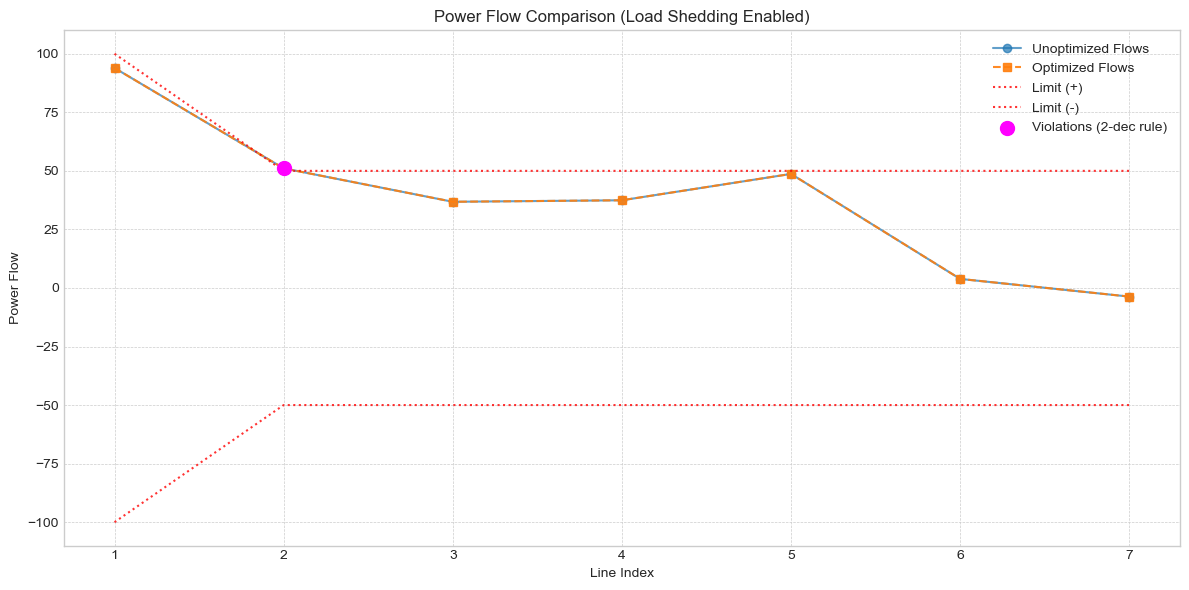

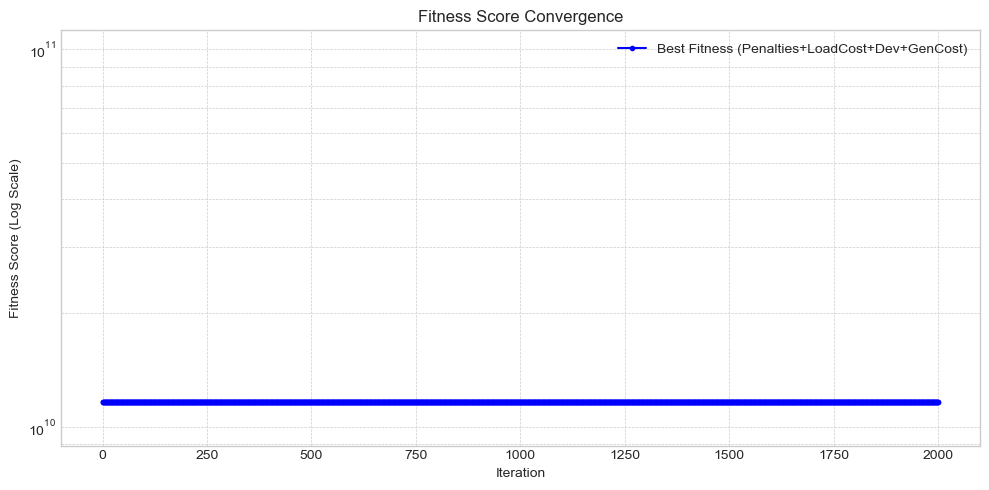

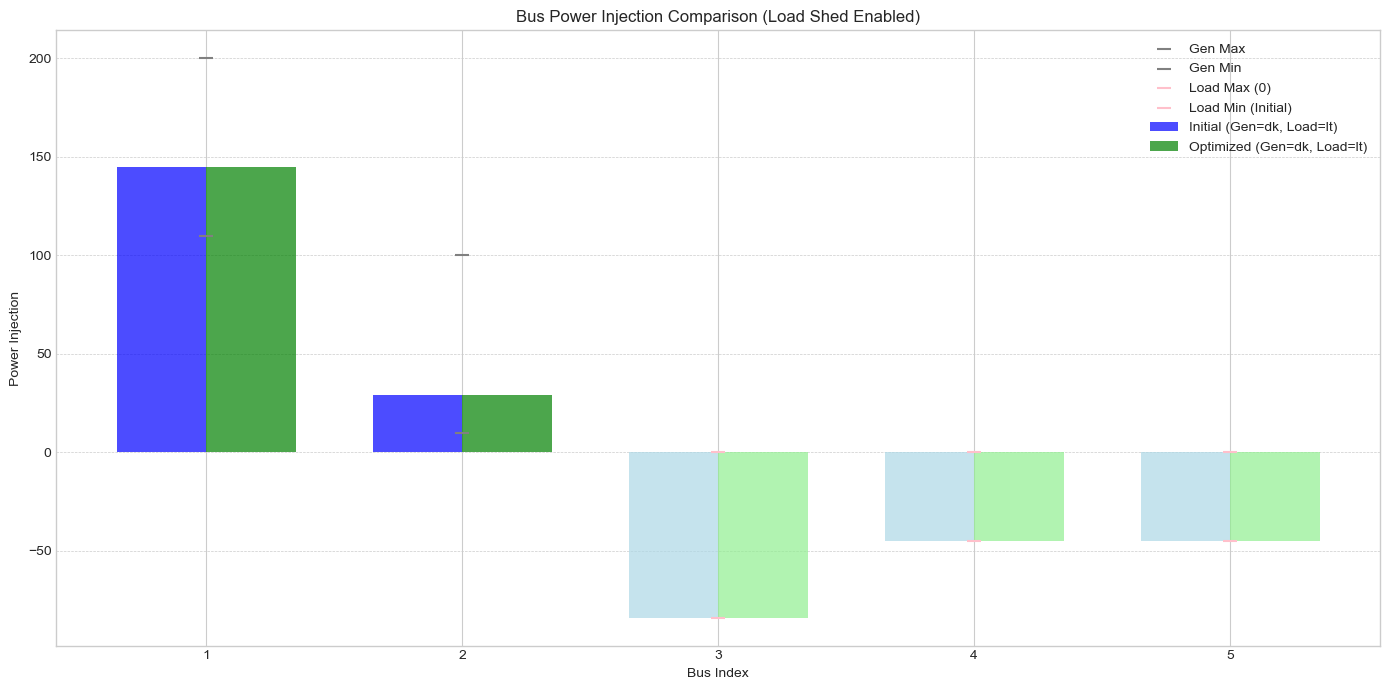

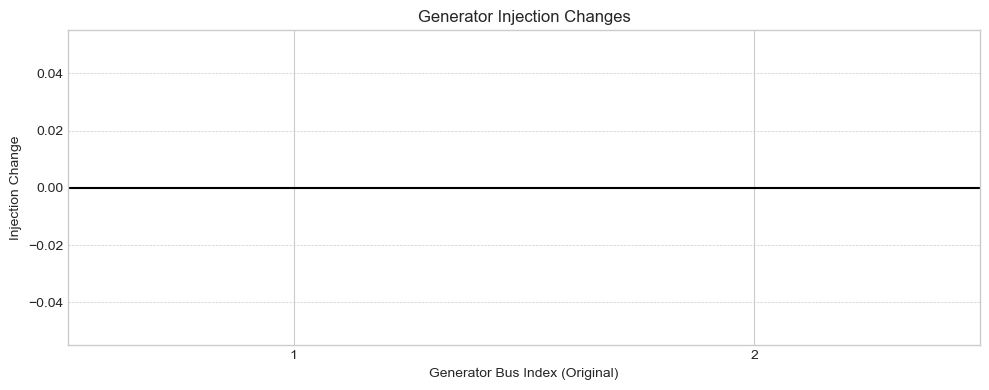

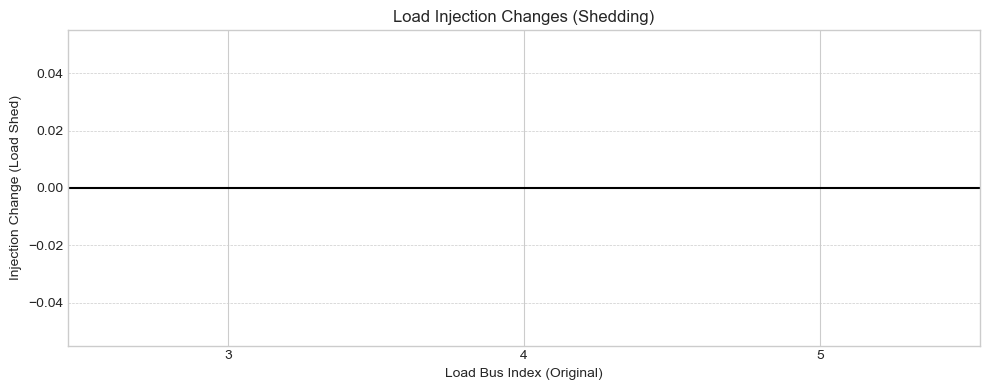


============================== RESULTS SUMMARY (Load Shedding Enabled) ==============================

Initial Power Injections (B):
 [145.  29. -84. -45. -45.]

Optimized Power Injections (B_optimized):
 [145.  29. -84. -45. -45.]

Sum of Optimized Injections (Balance Check): 0.000000

Initial Line Flows:
 [93.92 51.08 36.8  37.44 48.69  3.86 -3.69]

Optimized Line Flows:
 [93.92 51.08 36.8  37.44 48.69  3.86 -3.69]
----------------------------------------------------------------------

Objective Metrics & Load Shed:
  Sum of Absolute Changes (Generators Only): 0.00
  Generator Rescheduling Cost: 0.00 $/hr
  Load Shedding Cost: 0.00 $/hr
  Total Load Shed: 0.00 MW

Constraint Check Report (Summary): See detailed DEBUG lines during run if INFEASIBLE
Identified 2 generator buses (indices: [0 1])
Identified 3 load buses (indices: [2 3 4]) - Load shedding enabled.
--- Feasibility Check FAILED ---
  Line constraints failed (Raw Flow Check). Failing lines: [2]
    Line 2: Flow=51.077700, L


Run another scenario? (y/n):  n



Exiting...


In [118]:
# Cell 5: Main execution block (Prioritize Constraints & Deviation)

# %matplotlib inline

if __name__ == "__main__":

    # --- Define System Matrix A ---
    A = np.array([
        [0.5857, -0.2571, -0.0428, -0.0857, -0.2000], 
        [0.2143,  0.0571, -0.1572, -0.1143, -0.0000],
        [0.0905,  0.1619, -0.1953, -0.1238,  0.0666],
        [0.1080,  0.1651, -0.1206, -0.1968,  0.0444],
        [0.1872,  0.2158,  0.0730,  0.0349, -0.5109],
        [0.1048,  0.0191,  0.4476, -0.4380, -0.1334],
        [0.0128, -0.0158,  0.1270,  0.1651, -0.2891]
    ])
    num_lines_main = A.shape[0]; num_buses_main = A.shape[1]

    # --- Main Loop for Scenarios ---
    while True:
        print("\n" + "="*25 + " New Scenario Setup (Prioritize Constraints & Deviation) " + "="*25)
        # Updated objective description
        print("Objective: 1. Meet Limits & Min Gen Deviation, 2. Min Load Shed Cost, 3. Min Gen Cost")

        # --- User Inputs (Same as before) ---
        # Line Limits
        print(f"\n>>> Enter LINE power limits ({num_lines_main} values):")
        try:
            # EXAMPLE: line_limits_input = np.array([100, 50, 50, 50, 50, 50, 50])
            line_limits_input = np.array([float(input(f"  Line {i+1} limit: ")) for i in range(num_lines_main)])
            line_limits_input = np.abs(line_limits_input)
        except ValueError: print("Invalid input."); continue

        # Initial Injections (B)
        print(f"\n>>> Enter INITIAL power injections (B) for ALL buses ({num_buses_main} values):")
        print("    (Positive for Generators, Negative for Loads)")
        try:
            # EXAMPLE: B_input_list = [147.0, 36.0, -31.0, -80.0, -72.0]
            B_input_list = [float(input(f"  Bus {i+1} injection: ")) for i in range(num_buses_main)]
            B_input = np.array(B_input_list).reshape(-1, 1)
            temp_gen_indices = np.where(B_input.flatten() > 1e-6)[0]; temp_load_indices = np.where(B_input.flatten() <= 1e-6)[0]
            if len(temp_gen_indices) == 0: print("ERROR: No generator buses found!"); continue
            print(f"-> Identified Gen buses: {temp_gen_indices+1}"); print(f"-> Identified Load buses: {temp_load_indices+1}")
        except ValueError: print("Invalid input."); continue

        # Generator Specific Inputs
        gen_costs_input = np.zeros(num_buses_main); gen_limits_min_input = np.zeros(num_buses_main); gen_limits_max_input = np.zeros(num_buses_main)
        print(f"\n>>> Enter GENERATOR specific data ONLY for buses {temp_gen_indices+1}:")
        try:
            print("  Enter Gen Cost Coefficients ($/MWh):")
            # EXAMPLE: gen_costs_input[temp_gen_indices] = [8.34, 8.34]
            for i in temp_gen_indices: gen_costs_input[i] = float(input(f"    Gen Bus {i+1} cost: "))
            print("  Enter Gen MIN Power Limits (MW):")
            # EXAMPLE: gen_limits_min_input[temp_gen_indices] = [110, 10]
            for i in temp_gen_indices: gen_limits_min_input[i] = float(input(f"    Gen Bus {i+1} min limit: "))
            print("  Enter Gen MAX Power Limits (MW):")
            # EXAMPLE: gen_limits_max_input[temp_gen_indices] = [200, 100]
            for i in temp_gen_indices: gen_limits_max_input[i] = float(input(f"    Gen Bus {i+1} max limit: "))
            if np.any(gen_limits_max_input[temp_gen_indices] < gen_limits_min_input[temp_gen_indices]): print("ERROR: Gen max < min."); continue
        except ValueError: print("Invalid input."); continue

        # Load Shedding Cost Input
        load_shed_costs_input = np.zeros(num_buses_main)
        print(f"\n>>> Enter LOAD SHEDDING costs ($/MWh) ONLY for Load buses {temp_load_indices+1}:")
        try:
            # EXAMPLE: load_shed_costs_input[temp_load_indices] = [1000, 1000, 1000]
            for i in temp_load_indices: load_shed_costs_input[i] = float(input(f"    Load Bus {i+1} shed cost: "))
        except ValueError: print("Invalid input."); continue

        # --- Run Optimization ---
        print("\n" + "="*25 + " Running Optimization (Prioritize Constraints & Deviation) " + "="*25)
        # Use the same wrapper function call, the logic change is inside the class
        B_optimized, fitness_history, C_optimized, C_unoptimized, final_feasible, opt_details = optimize_power_flow_cost(
            A, B_input, line_limits_input, gen_costs_input, gen_limits_min_input, gen_limits_max_input, load_shed_costs_input,
            iterations=2000 # Keep increased iterations
        )

        print("\n" + "="*25 + " Optimization Finished " + "="*25)

        # --- Visualize Results ---
        viz_gen_indices = opt_details.get("gen_indices", np.array([])); viz_load_indices = opt_details.get("load_indices", np.array([]))
        print("\nVisualizing results...")
        # Pass all necessary args, including costs for reporting
        visualize_results(A, B_input, B_optimized, C_optimized, C_unoptimized, line_limits_input,
                          gen_costs_input, gen_limits_min_input, gen_limits_max_input, load_shed_costs_input,
                          viz_gen_indices, viz_load_indices,
                          fitness_history)

        # --- Save Results (Optional) ---
        if final_feasible:
            save = input("\nSave detailed results to file? (y/n): ").strip().lower()
            if save == 'y':
                fname = input("Enter filename (default: power_flow_dev_priority_results.txt): ").strip() or "power_flow_dev_priority_results.txt"
                try:
                    with open(fname, 'w') as f:
                         # Recalculate final metrics
                        gen_costs_only_save=gen_costs_input[viz_gen_indices]; final_gen_cost=np.sum(gen_costs_only_save*np.abs(B_optimized.flatten()[viz_gen_indices]-B_input.flatten()[viz_gen_indices]))
                        final_deviation_gens=np.sum(np.abs(B_optimized.flatten()[viz_gen_indices]-B_input.flatten()[viz_gen_indices]))
                        load_shed_costs_only_save=load_shed_costs_input[viz_load_indices]; load_shed_amount=np.maximum(0,B_optimized.flatten()[viz_load_indices]-B_input.flatten()[viz_load_indices]); final_load_shed_cost=np.sum(load_shed_costs_only_save*load_shed_amount); total_load_shed=np.sum(load_shed_amount)

                        f.write("Power Flow Opt Results (Constraints & Dev Priority)\n"); f.write("="*30+"\n\n")
                        f.write(f"Matrix A:\n"); np.savetxt(f, A, fmt='%.4f'); f.write("\n")
                        f.write("Line Limits:\n"); [f.write(f"L{i+1}: {l:.2f}\n") for i,l in enumerate(line_limits_input)]
                        f.write("\nGen Costs:\n"); [f.write(f"G Bus {viz_gen_indices[i]+1}: {c:.2f}\n") for i,c in enumerate(gen_costs_only_save)]
                        f.write("\nGen Min Limits:\n"); [f.write(f"G Bus {idx+1}: {gen_limits_min_input[idx]:.2f}\n") for idx in viz_gen_indices]
                        f.write("\nGen Max Limits:\n"); [f.write(f"G Bus {idx+1}: {gen_limits_max_input[idx]:.2f}\n") for idx in viz_gen_indices]
                        f.write("\nLoad Shed Costs:\n"); [f.write(f"L Bus {viz_load_indices[i]+1}: {c:.2f}\n") for i,c in enumerate(load_shed_costs_only_save)]
                        f.write("\nInitial B:\n"); [f.write(f"Bus {i+1}: {b[0]:.2f}\n") for i,b in enumerate(B_input)]
                        f.write("\nOptimized B:\n"); [f.write(f"Bus {i+1}: {b[0]:.2f}\n") for i,b in enumerate(B_optimized)]
                        f.write("\nInitial C:\n"); [f.write(f"L{i+1}: {c[0]:.2f}\n") for i,c in enumerate(C_unoptimized)]
                        f.write("\nOptimized C:\n"); [f.write(f"L{i+1}: {c[0]:.2f}\n") for i,c in enumerate(C_optimized)]
                        f.write(f"\nFinal Gen Deviation: {final_deviation_gens:.2f}\n"); f.write(f"Final Gen Cost: {final_gen_cost:.2f}\n"); f.write(f"Final Load Shed Cost: {final_load_shed_cost:.2f}\n"); f.write(f"Total Load Shed: {total_load_shed:.2f}\n")
                        f.write(f"\nFeasible: {'YES' if final_feasible else 'NO'}\n")
                    print(f"Results saved to {fname}")
                except IOError as e: print(f"Error saving results: {e}")
        elif not final_feasible: print("\nFinal solution was infeasible.")

        # --- Repeat? ---
        if input("\nRun another scenario? (y/n): ").strip().lower() != 'y': print("\nExiting..."); break
        else: print("\nRestarting...\n")